# IMPORTS

In [1]:
import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s') # NOTSET, DEBUG, INFO, WARN, ERROR, CRITICAL

import os, sys
import torch
import numpy as np

import CL_inference as cl_inference
N_threads = cl_inference.train_tools.set_N_threads_(N_threads=1)
torch.set_num_threads(N_threads)
torch.set_num_interop_threads(N_threads)
device = cl_inference.train_tools.set_torch_device_()

%load_ext autoreload

import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib notebook
plt.style.use('default')
plt.close('all')
font, rcnew = cl_inference.plot_utils.matplotlib_default_config()
mpl.rc('font', **font)
plt.rcParams.update(rcnew)
plt.style.use('tableau-colorblind10')
%config InlineBackend.figure_format = 'retina'

2024-07-24 18:58:42,227 - INFO - N_threads: 1
2024-07-24 18:58:42,268 - INFO - Device: cuda


# Select Runs

In [2]:
threshold = 2.

In [3]:
# models_path = "/cosmos_storage/home/dlopez/Projects/CL_inference/models_box_5000/"
models_path = "/cosmos_storage/home/dlopez/Projects/CL_inference/models/"

main_name = 'only_inference_models_illustris_eagle_kmax_0.6'
# main_name = 'only_inference_CL_Wein_models_illustris_eagle_kmax_0.6'
model_name_broadest = "Model_vary_all"

models_path = os.path.join(models_path, main_name)

# Check loss of runs & get config files of N_best_runs

In [4]:
select_N_best_runs = 1

<IPython.core.display.Javascript object>


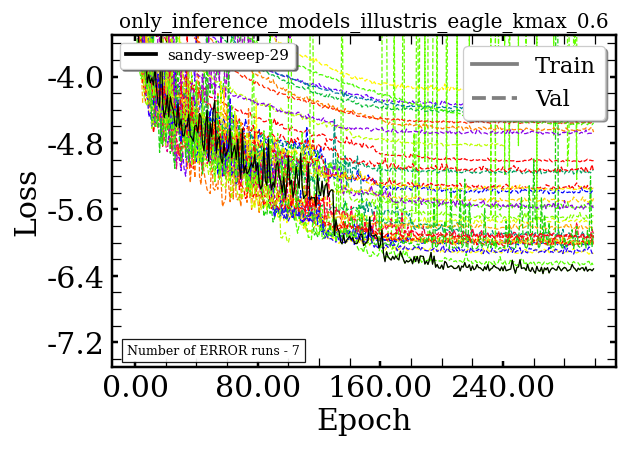

2024-07-24 18:58:43,623 - WARNING - Not value for keywandb_version in sandy-sweep-29


<IPython.core.display.Javascript object>


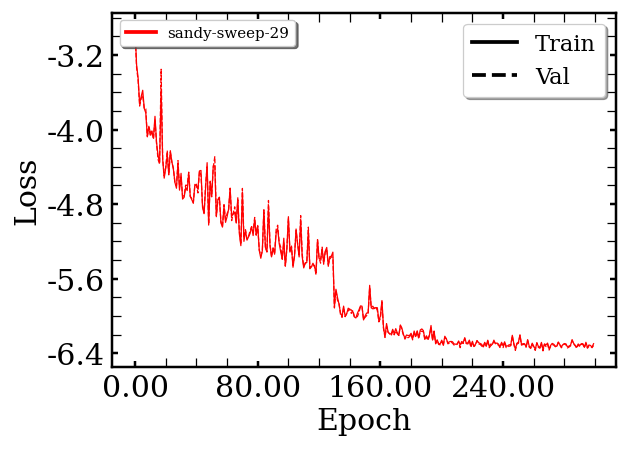

In [5]:
configs = cl_inference.plot_utils.get_config_files(
    models_path, select_N_best_runs=select_N_best_runs,
    wandb_entity="daniellopezcano"
)

# Reload Models

In [6]:
# evalute_mode = 'eval_CL' # "eval_CL", "eval_CL_and_inference", "eval_inference_supervised"
if "only_CL" in main_name:
    evalute_mode = 'eval_CL'
else:
    evalute_mode = 'eval_CL_and_inference'
    
models_encoder, models_inference = cl_inference.evaluation_tools.reload_models(models_path, evalute_mode, configs, device)

2024-07-24 18:58:44,092 - INFO - Loaded model encoder: sandy-sweep-29
2024-07-24 18:58:44,193 - INFO - Loaded model inference: sandy-sweep-29


# Load datasets

In [7]:
dset_name = "TEST"

In [8]:
key0_dset = list(configs.keys())[0]
sweep_name_load_norm_dset = key0_dset
save_root = configs[key0_dset]["path_save"]
config = configs[sweep_name_load_norm_dset]

### Complete some config default values (be carefull with this)

In [9]:
# list_model_names = config["list_model_names"]
list_model_names = [model_name_broadest]

In [10]:
try:
    print("include_baryon_params:", config['include_baryon_params'])
except:
    config['include_baryon_params'] = False
include_baryon_params = config['include_baryon_params']

try:
    print("dset_type:", config['dset_type'])
except:
    config['dset_type'] = "baccoemu"
dset_type = config['dset_type']

try:
    print("dset_dict:", config['dset_dict'])
except:
    config['dset_dict'] = {
        "add_noise_Pk" : "cosmic_var_gauss",
        "kmax"         : 0.6
    }
    try:
        print("box:", config['box'])
        config['dset_dict'].update({'box' : config['box']})
    except:
        config['dset_dict'].update({'box' : 2000})
    try:
        print("factor_kmin_cut:", config['factor_kmin_cut'])
        config['dset_dict'].update({'factor_kmin_cut' : config['factor_kmin_cut']})
    except:
        config['dset_dict'].update({'factor_kmin_cut' : 4})

In [11]:
custom_titles, limits_plots_inference, list_range_priors, xx_domain, colors, thresholds_bias, NN_bins_hist_bias, NN_bins_hist_err, NN_avail_cosmo_test, NN_split, max_err_hist = cl_inference.plot_utils.get_titles_limits_priors_and_colors_dset_models(
    dset_type             = config['dset_type'],
    dset_dict             = config['dset_dict'],
    list_model_names      = list_model_names,
    include_baryon_params = config['include_baryon_params']
)

In [12]:
dsets = {}
dsets[dset_name] = cl_inference.data_tools.def_data_loader(
    path_load             = os.path.join(config['path_load'], dset_name),
    list_model_names      = list_model_names,
    dset_type             = dset_type,
    dset_dict             = config['dset_dict'],
    include_baryon_params = include_baryon_params,
    normalize             = config['normalize'],
    path_load_norm        = os.path.join(config['path_save'], sweep_name_load_norm_dset),
    NN_augs_batch         = config['NN_augs_batch']
)

theta_true, xx, aug_params, indexes_cosmo, indexes_augs = dsets[dset_name](
    batch_size=0, seed=0, to_torch=True, device=device, use_all_dataset_augs_ordered=True, return_indexes_sampled=True
)

2024-07-24 18:58:44,248 - INFO - Defining data loader...
2024-07-24 18:58:44,249 - INFO - Loading stored data...
2024-07-24 18:58:44,250 - INFO - Loading Model_vary_all...
2024-07-24 18:58:44,281 - INFO - Initializing data loader...
2024-07-24 18:58:44,282 - INFO - Loading normalization parameters...


<IPython.core.display.Javascript object>


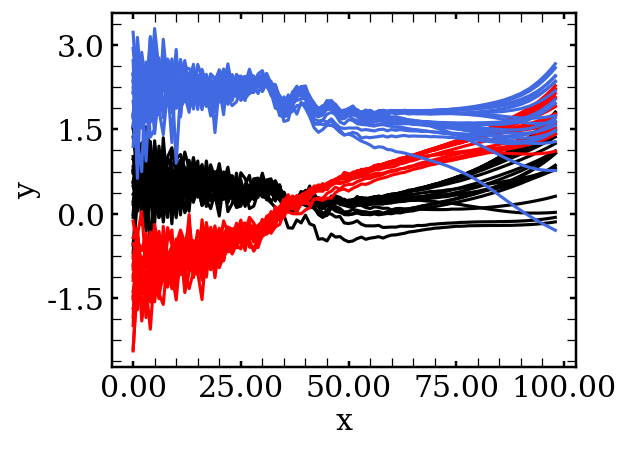

<IPython.core.display.Javascript object>


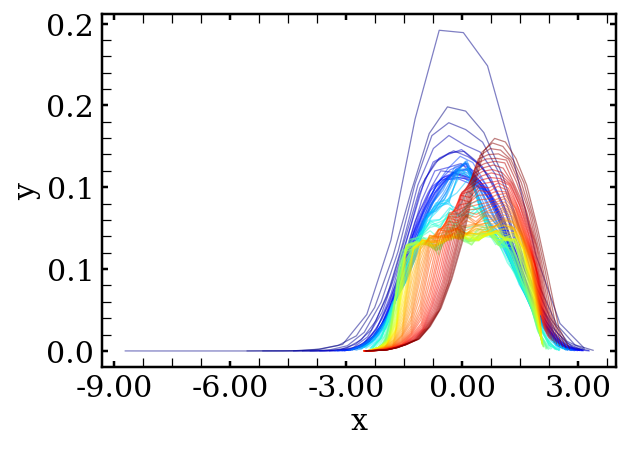

<IPython.core.display.Javascript object>


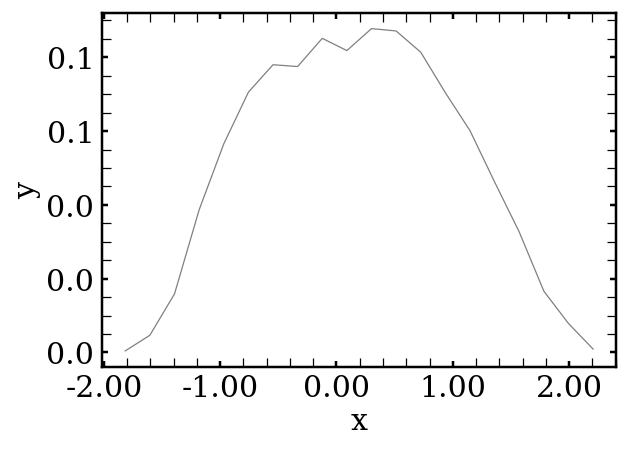

<IPython.core.display.Javascript object>


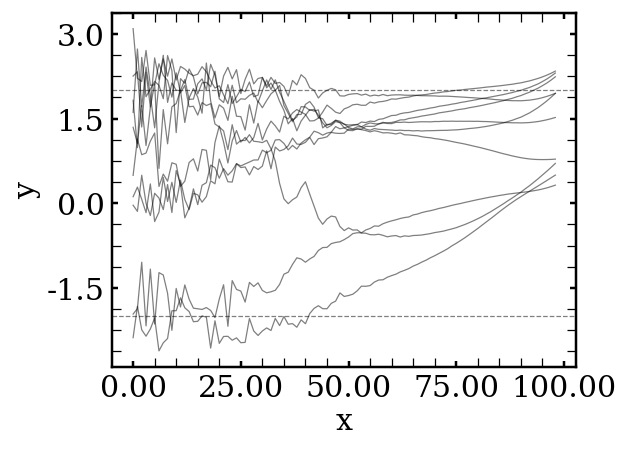

In [13]:
fig, ax = cl_inference.plot_utils.simple_plot()
ax.plot(xx[0,:].cpu().detach().numpy().T, c='k')
ax.plot(xx[1,:].cpu().detach().numpy().T, c='red')
ax.plot(xx[-1,:].cpu().detach().numpy().T, c='royalblue')
fig.set_tight_layout(True)
plt.show()


fig, ax = cl_inference.plot_utils.simple_plot()
colors = cl_inference.plot_utils.get_N_colors(xx.shape[-1], mpl.colormaps['jet'])
for ii in range(xx.shape[-1]):
    tmp_hist = xx[..., ii].cpu().detach().numpy().flatten()
    min_x, max_x = np.min(tmp_hist), np.max(tmp_hist)
    counts, bin_edges = np.histogram(tmp_hist, bins=20, range=(min_x, max_x))
    bin_centers = (bin_edges[1:] + bin_edges[:-1])/2
    tmp_y_hist = np.array(counts/np.sum(counts))
    ax.plot(bin_centers, tmp_y_hist, color=colors[ii], lw=1, alpha=0.5)
fig.set_tight_layout(True)
plt.show()


tmp_xx = np.reshape(xx.cpu().detach().numpy(), (xx.shape[0]*xx.shape[1], xx.shape[-1]))
mean_dist_Pk = np.mean(tmp_xx, axis=-1)


fig, ax = cl_inference.plot_utils.simple_plot()
tmp_hist = mean_dist_Pk
min_x, max_x = np.min(tmp_hist), np.max(tmp_hist)
counts, bin_edges = np.histogram(tmp_hist, bins=20, range=(min_x, max_x))
bin_centers = (bin_edges[1:] + bin_edges[:-1])/2
tmp_y_hist = np.array(counts/np.sum(counts))
ax.plot(bin_centers, tmp_y_hist, color='k', lw=1, alpha=0.5)
fig.set_tight_layout(True)
plt.show()


indexes_outlayers = np.where(np.abs(tmp_xx) > threshold)[0]
tmp_xx = tmp_xx[indexes_outlayers]

fig, ax = cl_inference.plot_utils.simple_plot()
idxs_plot = np.random.choice(tmp_xx.shape[0], 10, replace=False)
ax.plot(tmp_xx[idxs_plot].T, c='k', lw=1, alpha=0.5)
ax.axhline(-threshold, c='k', lw=1, alpha=0.5, ls='--')
ax.axhline(threshold, c='k', lw=1, alpha=0.5, ls='--')
# ax.set_ylim([-3, 3])
fig.set_tight_layout(True)
plt.show()

In [14]:
theta_true = torch.repeat_interleave(theta_true, xx.shape[1], axis=0)
if aug_params is not None:
    aug_params = torch.reshape(aug_params, (aug_params.shape[0]*aug_params.shape[1], aug_params.shape[-1]))
    theta_true = torch.concatenate((theta_true, aug_params), axis=-1)
theta_true = theta_true.cpu().detach().numpy()


tmp_xx = np.reshape(xx.cpu().detach().numpy(), (xx.shape[0]*xx.shape[1], xx.shape[-1]))

indexes_outlayers = np.sum(np.abs(tmp_xx[..., -30:]) > threshold, axis=-1) == 0

tmp_xx = tmp_xx[indexes_outlayers]
tmp_xx = torch.from_numpy(tmp_xx.astype(np.float32)).to(device)

theta_true = theta_true[indexes_outlayers]


NN_params_out = config["NN_params_out"]
thetas_pred = np.zeros((len(models_encoder.keys()), tmp_xx.shape[0], NN_params_out))
Covs = np.zeros((len(models_encoder.keys()), tmp_xx.shape[0], NN_params_out, NN_params_out))
hh = {}
for ii, sweep_name in enumerate(models_encoder.keys()):
    hh[sweep_name] = models_encoder[sweep_name](tmp_xx.contiguous())

    if models_inference[sweep_name] != None:
        yy = models_inference[sweep_name](hh[sweep_name].contiguous())

        theta_pred, cov_pred = yy[:, :theta_true.shape[-1]], yy[:, theta_true.shape[-1]:]
        Cov = cl_inference.custom_loss_functions.vector_to_Cov(cov_pred).to(device)

        thetas_pred[ii] = theta_pred.cpu().detach().numpy()
        Covs[ii] = Cov.cpu().detach().numpy()

    hh[sweep_name] = hh[sweep_name].cpu().detach().numpy()
    
theta_pred = np.mean(thetas_pred, axis=0)
Cov = np.mean(Covs, axis=0)


tmp_xx = tmp_xx.cpu().detach().numpy()

<IPython.core.display.Javascript object>


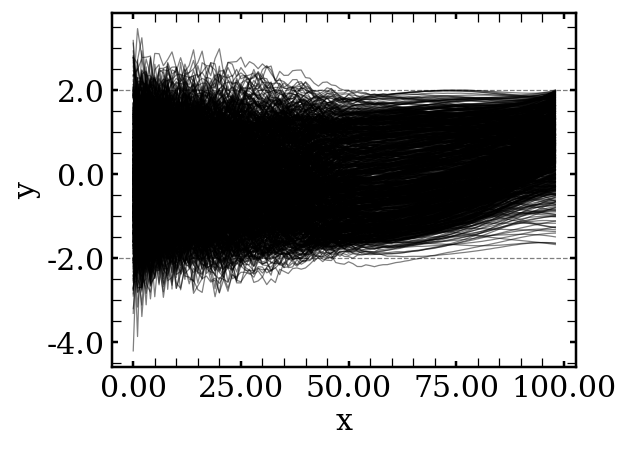

In [15]:
fig, ax = cl_inference.plot_utils.simple_plot()
idxs_plot = np.random.choice(tmp_xx.shape[0], 1000, replace=False)
ax.plot(tmp_xx[idxs_plot].T, c='k', lw=1, alpha=0.5)
ax.axhline(-threshold, c='k', lw=1, alpha=0.5, ls='--')
ax.axhline(threshold, c='k', lw=1, alpha=0.5, ls='--')
fig.set_tight_layout(True)
plt.show()

In [16]:
tmp_xx.shape

(37576, 99)

In [17]:
theta_pred.shape

(37576, 5)

In [18]:
theta_true.shape

(37576, 5)

In [19]:
fig, axs = cl_inference.plot_utils.plot_inference_split_models(
    list_model_names,
    [1],
    theta_true[:,np.newaxis],
    theta_pred[:,np.newaxis],
    Cov[:,np.newaxis],
    custom_titles=custom_titles,
    limits_plots=limits_plots_inference,
    colors=['grey']
)
fig.suptitle(main_name, size=18)
fig.set_tight_layout(True)
fig.savefig(save_root + "/eval_inference_selected_"+str(threshold)+".png")

<IPython.core.display.Javascript object>

In [20]:
NN_avail_cosmo_test = theta_true.shape[0]
NN_params = theta_true.shape[-1]
NN_split = 20
NN_bins_hist = 60

indexes_cosmos = np.arange(theta_true.shape[0])
np.random.shuffle(indexes_cosmos)
indexes_cosmos_groups = np.split(indexes_cosmos, (np.arange(NN_split)+1) * int(NN_avail_cosmo_test/NN_split))[:-1]

fraction_biased = np.zeros((len(indexes_cosmos_groups), len(list_model_names), NN_params, len(thresholds_bias)))
NN_points = np.zeros((len(indexes_cosmos_groups), len(list_model_names), NN_params))
bin_centers = np.zeros((len(indexes_cosmos_groups), len(list_model_names), NN_params, NN_bins_hist+2))
y_hists = np.zeros((len(indexes_cosmos_groups), len(list_model_names), NN_params, NN_bins_hist+2))
bin_centers_err = np.zeros((len(indexes_cosmos_groups), len(list_model_names), NN_params, NN_bins_hist_err+2))
y_hists_err = np.zeros((len(indexes_cosmos_groups), len(list_model_names), NN_params, NN_bins_hist_err+2))
median_err = np.zeros((len(indexes_cosmos_groups), len(list_model_names), NN_params))
std_err = np.zeros((len(indexes_cosmos_groups), len(list_model_names), NN_params))
ii_aug = 0
for ii_model_name, list_model_name in enumerate(list_model_names):
    for ii, indexes_cosmos in enumerate(indexes_cosmos_groups):

        # --------------------------- compute_bias_hist_augs --------------------------- #

        bin_edges, tmp_bin_centers, tmp_y_hists, tmp_NN_points = cl_inference.evaluation_tools.compute_bias_hist_augs(
            theta_true[indexes_cosmos, np.newaxis], theta_pred[indexes_cosmos, np.newaxis], Cov[indexes_cosmos, np.newaxis], min_x=-6, max_x=6, bins=NN_bins_hist
        )
        tmp_bin_centers = np.insert(tmp_bin_centers, 0, bin_edges[..., 0], axis=-1)
        tmp_bin_centers = np.insert(tmp_bin_centers, bin_edges.shape[-1], bin_edges[..., -1], axis=-1)

        fraction_biased_list = np.zeros((tmp_y_hists.shape[0], len(thresholds_bias)))
        for jj in range(len(thresholds_bias)):
            mask = np.abs(tmp_bin_centers) > thresholds_bias[jj]
            for kk in range(tmp_y_hists.shape[0]):
                fraction_biased_list[kk, jj] = np.sum(tmp_y_hists[kk,ii_aug][mask[kk,ii_aug]]) / tmp_NN_points[kk,ii_aug]

        fraction_biased[ii, ii_model_name] = fraction_biased_list
        bin_centers[ii, ii_model_name] = tmp_bin_centers[:,ii_aug]
        y_hists[ii, ii_model_name] = tmp_y_hists[:,ii_aug]
        NN_points[ii, ii_model_name] = tmp_NN_points[:,ii_aug]

        # --------------------------- compute_err_hist_augs --------------------------- #

        bin_edges_err, tmp_bin_centers_err, tmp_y_hists_err, tmp_median_err, tmp_std_err = cl_inference.evaluation_tools.compute_err_hist_augs(
            Cov[indexes_cosmos, np.newaxis], max_x=max_err_hist, bins=NN_bins_hist_err
        )
        tmp_bin_centers_err = np.insert(tmp_bin_centers_err, 0, bin_edges_err[..., 0], axis=-1)
        tmp_bin_centers_err = np.insert(tmp_bin_centers_err, bin_edges_err.shape[-1], bin_edges_err[..., -1], axis=-1)

        bin_centers_err[ii, ii_model_name] = tmp_bin_centers_err[:,ii_aug]
        y_hists_err[ii, ii_model_name] = tmp_y_hists_err[:,ii_aug]
        median_err[ii, ii_model_name] = tmp_median_err[:,ii_aug]
        std_err[ii, ii_model_name] = tmp_std_err[:,ii_aug]
        
np.save(save_root + "/fraction_biased_batches_selected_"+str(threshold)+".npy", fraction_biased)
np.save(save_root + "/NN_points_batches_selected_"+str(threshold)+".npy", NN_points)
np.save(save_root + "/bin_centers_batches_selected_"+str(threshold)+".npy", bin_centers)
np.save(save_root + "/y_hists_batches_selected_"+str(threshold)+".npy", y_hists)
np.save(save_root + "/bin_centers_err_batches_selected_"+str(threshold)+".npy", bin_centers_err)
np.save(save_root + "/y_hists_err_batches_selected_"+str(threshold)+".npy", y_hists_err)
np.save(save_root + "/median_err_batches_selected_"+str(threshold)+".npy", median_err)
np.save(save_root + "/std_err_batches_selected_"+str(threshold)+".npy", std_err)

In [21]:
fraction_biased_batches = np.load(save_root + "/fraction_biased_batches_selected_"+str(threshold)+".npy")
NN_points_batches = np.load(save_root + "/NN_points_batches_selected_"+str(threshold)+".npy")
bin_centers_batches = np.load(save_root + "/bin_centers_batches_selected_"+str(threshold)+".npy")
y_hists_batches = np.load(save_root + "/y_hists_batches_selected_"+str(threshold)+".npy")
bin_centers_err_batches = np.load(save_root + "/bin_centers_err_batches_selected_"+str(threshold)+".npy")
y_hists_err_batches = np.load(save_root + "/y_hists_err_batches_selected_"+str(threshold)+".npy")
NN_points_batches = np.load(save_root + "/median_err_batches_selected_"+str(threshold)+".npy")
std_err_batches = np.load(save_root + "/std_err_batches_selected_"+str(threshold)+".npy")

In [22]:
fraction_biased_batches.shape

(20, 1, 5, 20)

<IPython.core.display.Javascript object>


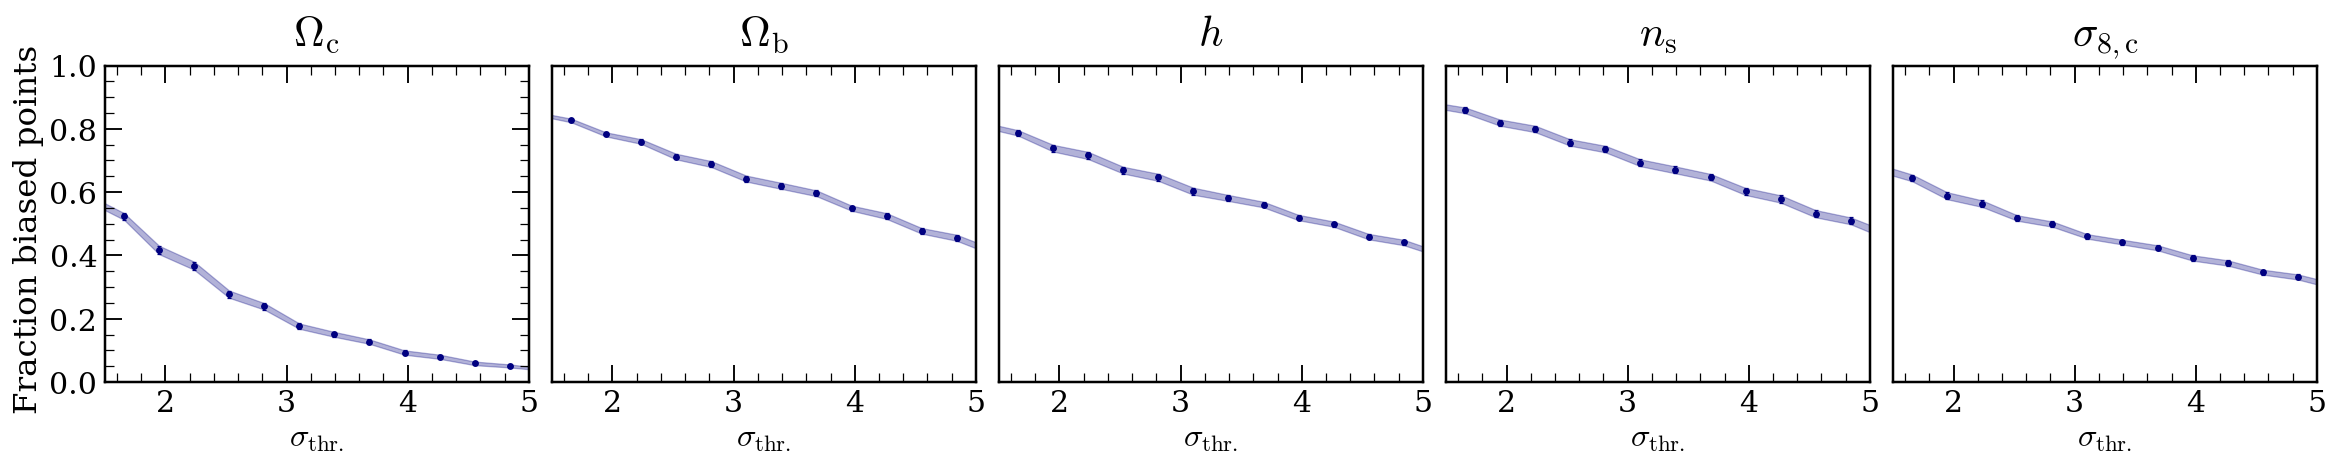

/tmp/ipykernel_429026/4186745349.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(thresholds_bias, tmp_mean, c=color, s=20)


In [23]:
fontsize=26
fontsize1=18
fig, axs = plt.subplots(1, len(custom_titles), figsize=(5.2*len(custom_titles), 5.2))
axs[0].set_ylabel(r'Fraction biased points ', size=fontsize)
for ii_cosmo_param in range(len(custom_titles)):
    ax = axs[ii_cosmo_param]
    ax.set_xlim([1.5, 5.])
    ax.set_ylim([0, 1])
    ax.set_title(custom_titles[ii_cosmo_param], size=fontsize+8, pad=16)
    ax.set_xlabel(r'$\sigma_\mathrm{thr.}$', size=fontsize)
    if ii_cosmo_param != 0:
        ax.set_yticks([])
    for ii_model_name, list_model_name in enumerate(list_model_names):
        color = colors[ii_model_name]
#         ax.plot(thresholds_bias, fraction_biased_batches[:, ii_model_name, ii_cosmo_param].T, c=color, lw=1)
        tmp_mean = np.nanmean(fraction_biased_batches[:, ii_model_name, ii_cosmo_param], axis=0)
        tmp_std = np.nanstd(fraction_biased_batches[:, ii_model_name, ii_cosmo_param], axis=0)
        ax.scatter(thresholds_bias, tmp_mean, c=color, s=20)
        ax.errorbar(thresholds_bias, tmp_mean, yerr=tmp_std, c=color, ls='', capsize=2, alpha=1., elinewidth=1.5)
        ax.fill_between(thresholds_bias, tmp_mean-tmp_std, tmp_mean+tmp_std, color=color, alpha=0.3)

fig.set_tight_layout(True)
fig.savefig(save_root + "/bias_vs_threshold.png")